# Chapter 3 - Determinants



## Section 3.1 - Introduction to Determinants

Main ideas: cofactor expansion, the sign of a determinant, geometric area, and experimental discovery of determinant identities.

# Section 3.1 - Exercise 43

Let $\mathbf u=\begin{bmatrix}3\\0\end{bmatrix}$ and $\mathbf v=\begin{bmatrix}1\\2\end{bmatrix}$. Compute the area of the parallelogram determined by $\mathbf u,\mathbf v,\mathbf u+\mathbf v,$ and $\mathbf 0$, and compute the determinant of $[\,\mathbf u\ \mathbf v\,]$. How do they compare? Replace the first entry of $\mathbf v$ by an arbitrary number $x$, and repeat the problem. Draw a picture and explain what you find.

## Solution

The matrix whose columns are $\mathbf u$ and $\mathbf v$ is

$$
[\,\mathbf u\ \mathbf v\,]=
\begin{bmatrix}3&1\\0&2\end{bmatrix},
\qquad
\det[\,\mathbf u\ \mathbf v\,]=3(2)-0(1)=6.
$$

Using $\mathbf u$ as the base, the base length is $3$ and the perpendicular height is $2$, so the area is $3\cdot2=6$. Thus the area equals $|\det[\,\mathbf u\ \mathbf v\,]|$.

If $\mathbf v=\begin{bmatrix}x\\2\end{bmatrix}$, then

$$
\det\begin{bmatrix}3&x\\0&2\end{bmatrix}=6.
$$

Changing $x$ shears the parallelogram horizontally, but its base and height do not change. Therefore its area remains $6$ for every real $x$.

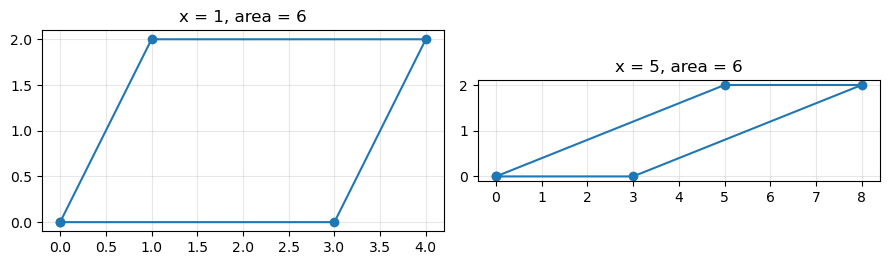

In [1]:
import matplotlib.pyplot as plt

# u = (3, 0)，v = (x, 2)。改变 x，比较两个平行四边形。
for x in [1, 5]:
    # 按顺序连接原点、u、u+v、v，最后回到原点。
    horizontal = [0, 3, 3 + x, x, 0]
    vertical = [0, 0, 2, 2, 0]

    # 二阶行列式：主对角线乘积减去另一条对角线乘积。
    det_A = 3 * 2 - 0 * x
    area = abs(det_A)  # 面积等于行列式的绝对值。
    print(f"x = {x}，行列式 = {det_A}，面积 = {area}")

    plt.figure(figsize=(5, 3))
    plt.plot(horizontal, vertical, marker="o")
    plt.fill(horizontal, vertical, alpha=0.2)
    plt.title(f"x = {x}, area = {area}")
    plt.axis("equal")  # 两个坐标轴使用相同的单位长度。
    plt.grid(True)
    plt.show()


# Section 3.1 - Exercise 44

Let $\mathbf u=\begin{bmatrix}a\\b\end{bmatrix}$ and $\mathbf v=\begin{bmatrix}c\\0\end{bmatrix}$, where $a,b,$ and $c$ are positive (for simplicity). Compute the area of the parallelogram determined by $\mathbf u,\mathbf v,\mathbf u+\mathbf v,$ and $\mathbf 0$, and compute the determinants of the matrices $[\,\mathbf u\ \mathbf v\,]$ and $[\,\mathbf v\ \mathbf u\,]$. Draw a picture and explain what you find.

## Solution

The vector $\mathbf v$ lies on the horizontal axis, so it gives a base of length $c$. The vertical height of $\mathbf u$ above this base is $b$. Hence

$$
\text{area}=bc.
$$

Also,

$$
\det[\,\mathbf u\ \mathbf v\,]
=\det\begin{bmatrix}a&c\\b&0\end{bmatrix}=-bc,
\qquad
\det[\,\mathbf v\ \mathbf u\,]
=\det\begin{bmatrix}c&a\\0&b\end{bmatrix}=bc.
$$

Both absolute values equal the area. Interchanging the two columns reverses the orientation and therefore reverses the sign of the determinant.

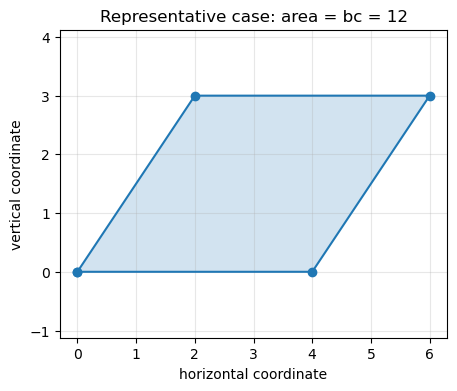

In [2]:
import matplotlib.pyplot as plt

# 选取一组正数，画出题目中的平行四边形。
a, b, c = 2, 3, 4
area = b * c  # 底边长为 c，高为 b。
det_uv = a * 0 - c * b  # 矩阵 [u v] 的行列式。
det_vu = c * b - a * 0  # 交换两列后，行列式变号。
print("面积 =", area)
print("det([u v]) =", det_uv)
print("det([v u]) =", det_vu)

# 顶点顺序：原点、v、u+v、u、原点。
horizontal = [0, c, a + c, a, 0]
vertical = [0, 0, b, b, 0]
plt.figure(figsize=(5, 4))
plt.plot(horizontal, vertical, marker="o")
plt.fill(horizontal, vertical, alpha=0.2)
plt.title(f"Area = b * c = {area}")
plt.xlabel("horizontal coordinate")
plt.ylabel("vertical coordinate")
plt.axis("equal")
plt.grid(True)
plt.show()


# Section 3.1 - Exercise 47

Construct a random $4\times4$ matrix $A$ with integer entries between $-9$ and $9$. How is $\det A^{-1}$ related to $\det A$? Experiment with random $n\times n$ integer matrices for $n=4,5,$ and $6$, and make a conjecture. Note: In the unlikely event that you encounter a matrix with a zero determinant, reduce it to echelon form and discuss what you find.

## Solution

The experiments suggest

$$
\boxed{\det(A^{-1})=\frac{1}{\det A}}
$$

whenever $A$ is invertible. This agrees with $AA^{-1}=I$ and, as proved in Section 3.2, the multiplicative property:

$$
1=\det I=\det(AA^{-1})=(\det A)(\det A^{-1}).
$$

If $\det A=0$, row reduction produces fewer than $n$ pivots, so $A^{-1}$ does not exist.

In [4]:
import numpy as np

rng = np.random.default_rng(47)  # 固定种子，让每次运行得到相同的随机矩阵。
for n in [4, 5, 6]:
    A = rng.integers(-9, 10, size=(n, n))  # 元素取 -9 到 9，右端的 10 不包含在内。
    det_A = np.linalg.det(A)  # det 用于计算行列式。
    print(f"\n{n} 阶矩阵 A：\n", A)
    print("det(A) =", det_A)

    # 计算机有舍入误差，用 isclose 判断结果是否接近 0。
    if np.isclose(det_A, 0):
        # 行阶梯形中的主元数等于秩；少于 n 个主元时没有逆矩阵。
        pivots = np.linalg.matrix_rank(A)
        print("主元数 =", pivots, "，矩阵不可逆。")
    else:
        A_inverse = np.linalg.inv(A)  # inv 用于计算逆矩阵。
        det_inverse = np.linalg.det(A_inverse)
        print("det(A 的逆矩阵) =", det_inverse)
        print("1 / det(A) =", 1 / det_A)
        print("两个行列式的乘积 =", det_A * det_inverse)


n=4: det(A)=-2700, det(A^-1)=-0.00037037037, product=1
n=5: det(A)=8862, det(A^-1)=0.00011284135, product=1
n=6: det(A)=212539, det(A^-1)=4.7050188e-06, product=1


# Section 3.1 - Exercise 48

Is it true that $\det(AB)=(\det A)(\det B)$? To find out, generate random $5\times5$ matrices $A$ and $B$, and compute $\det(AB)-(\det A\det B)$. Repeat the calculations for three other pairs of $n\times n$ matrices, for various values of $n$. Report your results.

## Solution

For every tested pair, $\det(AB)-(\det A)(\det B)$ is zero up to floating-point roundoff. The conjecture is

$$
\boxed{\det(AB)=(\det A)(\det B)},
$$

which is proved as Theorem 6 in Section 3.2.

In [4]:
import numpy as np

rng = np.random.default_rng(48)  # 固定种子，便于重复实验。
for n in [5, 2, 3, 4]:
    A = rng.integers(-5, 6, size=(n, n))
    B = rng.integers(-5, 6, size=(n, n))
    AB = A @ B  # @ 表示矩阵乘法，* 表示对应元素相乘。

    det_AB = np.linalg.det(AB)
    det_A = np.linalg.det(A)
    det_B = np.linalg.det(B)
    difference = det_AB - det_A * det_B
    print(f"{n} 阶：det(AB) - det(A) * det(B) = {difference}")
    # 差值应接近 0；很小的非零值可能来自浮点舍入误差。


n=5: difference = -3.492460e-10
n=2: difference = 5.684342e-14
n=3: difference = 9.094947e-13
n=4: difference = 2.910383e-11


# Section 3.1 - Exercise 49

Is it true that $\det(A+B)=\det A+\det B$? Experiment with four pairs of random matrices as in Exercise 48, and make a conjecture.

## Solution

The experiments give clear counterexamples. Therefore,

$$
\boxed{\det(A+B)\ne\det A+\det B\quad\text{in general}.}
$$

The determinant is linear in one column when the other columns are held fixed, but it is not a linear function of the whole matrix.

In [1]:
import numpy as np

rng = np.random.default_rng(49)  # 用四组随机矩阵检验加法关系。
for n in [2, 3, 4, 5]:
    A = rng.integers(-4, 5, size=(n, n))
    B = rng.integers(-4, 5, size=(n, n))

    det_sum = np.linalg.det(A + B)  # 先把矩阵相加，再求行列式。
    sum_det = np.linalg.det(A) + np.linalg.det(B)  # 先分别求行列式，再相加。
    print(f"\n{n} 阶矩阵：")
    print("det(A + B) =", det_sum)
    print("det(A) + det(B) =", sum_det)
    # 比较结果可见：行列式一般不满足这种加法关系。


n=2: det(A+B)=-10, det(A)+det(B)=-5
n=3: det(A+B)=-32, det(A)+det(B)=-62
n=4: det(A+B)=412, det(A)+det(B)=-130
n=5: det(A+B)=2244, det(A)+det(B)=320


# Section 3.1 - Exercise 50

Construct a random $4\times4$ matrix $A$ with integer entries between $-9$ and $9$, and compare $\det A$ with $\det A^T$, $\det(-A)$, $\det(2A)$, and $\det(10A)$. Repeat with two other random $4\times4$ integer matrices, and make conjectures about how these determinants are related. Then check your conjectures with several random $5\times5$ and $6\times6$ integer matrices. Modify your conjectures, if necessary, and report your results.

## Solution

The experiments support the general identities for an $n\times n$ matrix:

$$
\boxed{\det(A^T)=\det A},\qquad
\boxed{\det(-A)=(-1)^n\det A},\qquad
\boxed{\det(cA)=c^n\det A}.
$$

For $4\times4$ matrices, $\det(-A)=\det A$, $\det(2A)=16\det A$, and $\det(10A)=10^4\det A$. The $5\times5$ test is important because it reveals the odd-dimensional sign change in $\det(-A)$.

In [2]:
import numpy as np

rng = np.random.default_rng(50)
# 先试三组 4 阶矩阵，再各试两组 5 阶和 6 阶矩阵。
for n in [4, 4, 4, 5, 5, 6, 6]:
    A = rng.integers(-9, 10, size=(n, n))
    det_A = np.linalg.det(A)
    print(f"\n{n} 阶矩阵，det(A) = {det_A}")
    print("det(A.T) =", np.linalg.det(A.T))  # .T 表示转置。

    # 所有 n 行都乘以 c，行列式就乘以 c 的 n 次方。
    for c in [-1, 2, 10]:
        actual = np.linalg.det(c * A)
        expected = c ** n * det_A  # ** 表示乘方。
        print(f"c = {c}：det(cA) = {actual}，c**n * det(A) = {expected}")


n=4: transpose ratio=1, negative ratio=1, 2A ratio=16, 10A ratio=10000
n=4: transpose ratio=1, negative ratio=1, 2A ratio=16, 10A ratio=10000
n=4: transpose ratio=1, negative ratio=1, 2A ratio=16, 10A ratio=10000
n=5: transpose ratio=1, negative ratio=-1, 2A ratio=32, 10A ratio=100000
n=6: transpose ratio=1, negative ratio=1, 2A ratio=64, 10A ratio=1000000


# Section 3.1 - Exercise 51

Recall from the introductory section that the larger the determinant of $D^TD$, where $D$ is the design matrix, the better will be the accuracy of the calculated weights for small light objects. Which of the following matrices corresponds to the best design for four weighings of four objects? Describe which of the objects $s_1,s_2,s_3,$ and $s_4$ you would put in the left and right pans for each weighing corresponding to the best design matrix.

$$
\text{(a) }D=\begin{bmatrix}1&1&1&1\\1&-1&1&1\\-1&-1&1&-1\\1&1&1&-1\end{bmatrix},\quad
\text{(b) }D=\begin{bmatrix}-1&-1&-1&-1\\1&-1&-1&1\\-1&1&-1&1\\-1&-1&1&1\end{bmatrix},
$$

$$
\text{(c) }D=\begin{bmatrix}1&1&-1&-1\\1&-1&-1&1\\-1&1&1&-1\\1&-1&1&-1\end{bmatrix}.
$$

## Solution

Computing $\det(D^TD)$ gives

$$
\text{(a) }64,\qquad \text{(b) }256,\qquad \text{(c) }0.
$$

Therefore **design (b)** is best. The textbook convention is $-1=$ left pan and $+1=$ right pan:

1. Weighing 1: left $s_1,s_2,s_3,s_4$; right none.
2. Weighing 2: left $s_2,s_3$; right $s_1,s_4$.
3. Weighing 3: left $s_1,s_3$; right $s_2,s_4$.
4. Weighing 4: left $s_1,s_2$; right $s_3,s_4$.

In [5]:
import numpy as np

# 每行对应一次称量，每列对应一个物体。
D_a = np.array([
    [1, 1, 1, 1],
    [1, -1, 1, 1],
    [-1, -1, 1, -1],
    [1, 1, 1, -1]
])
D_b = np.array([
    [-1, -1, -1, -1],
    [1, -1, -1, 1],
    [-1, 1, -1, 1],
    [-1, -1, 1, 1]
])
D_c = np.array([
    [1, 1, -1, -1],
    [1, -1, -1, 1],
    [-1, 1, 1, -1],
    [1, -1, 1, -1]
])

# .T 是转置，@ 是矩阵乘法。比较三个 det(D.T @ D)。
score_a = round(np.linalg.det(D_a.T @ D_a))
score_b = round(np.linalg.det(D_b.T @ D_b))
score_c = round(np.linalg.det(D_c.T @ D_c))
# 理论结果为整数，round 消除计算中的微小舍入误差。
print("方案 a：", score_a)
print("方案 b：", score_b)
print("方案 c：", score_c)
print("行列式最大的方案 b 最好：-1 放左盘，+1 放右盘。")


Design a: det(D^T D) = 64
Design b: det(D^T D) = 256
Design c: det(D^T D) = 0


## Section 3.2 - Properties of Determinants



# Section 3.2 - Exercise 37

Show that if $A$ is invertible, then $\det A^{-1}=\dfrac{1}{\det A}$.

## Solution

Because $A$ is invertible, $AA^{-1}=I$. By Theorem 6,

$$
1=\det I=\det(AA^{-1})=(\det A)(\det A^{-1}).
$$

Theorem 4 gives $\det A\ne0$, so division is valid:

$$
\boxed{\det A^{-1}=\frac{1}{\det A}}.
$$



# Section 3.2 - Exercise 38

Suppose that $A$ is a square matrix such that $\det A^3=0$. Explain why $A$ cannot be invertible.

## Solution

By Theorem 6,

$$
\det(A^3)=\det(AAA)=(\det A)^3.
$$

Thus $(\det A)^3=0$, which implies $\det A=0$. By Theorem 4, $A$ is not invertible.



# Section 3.2 - Exercise 39

Let $A$ and $B$ be square matrices. Show that even though $AB$ and $BA$ may not be equal, it is always true that $\det AB=\det BA$.

## Solution

Using Theorem 6 and commutativity of ordinary scalar multiplication,

$$
\det(AB)=(\det A)(\det B)=(\det B)(\det A)=\det(BA).
$$



# Section 3.2 - Exercise 40

Let $A$ and $P$ be square matrices, with $P$ invertible. Show that $\det(PAP^{-1})=\det A$.

## Solution

By Theorem 6 and Exercise 37,

$$
\det(PAP^{-1})=(\det P)(\det A)(\det P^{-1})
=(\det P)(\det A)\frac{1}{\det P}=\det A.
$$



# Section 3.2 - Exercise 41

Let $U$ be a square matrix such that $U^TU=I$. Show that $\det U=\pm1$.

## Solution

Using Theorems 5 and 6,

$$
1=\det I=\det(U^TU)=\det(U^T)\det U=(\det U)^2.
$$

Therefore

$$
\boxed{\det U=\pm1}.
$$



# Section 3.2 - Exercise 42

Find a formula for $\det(rA)$ when $A$ is an $n\times n$ matrix.

## Solution

Multiplying $A$ by $r$ multiplies each of its $n$ rows by $r$. Theorem 3(c) contributes one factor of $r$ for each row, so

$$
\boxed{\det(rA)=r^n\det A}.
$$

Equivalently, $rA=(rI)A$, and Theorem 6 gives $\det(rA)=\det(rI)\det A=r^n\det A$.



# Section 3.2 - Exercise 51

Suppose $A$ is an $n\times n$ matrix and a computer suggests that $\det A=5$ and $\det(A^{-1})=1$. Should you trust these answers? Why or why not?

## Solution

No. Exercise 37 requires

$$
\det(A^{-1})=\frac{1}{\det A}=\frac15,
$$

or equivalently $(\det A)(\det A^{-1})=1$. The reported values give $5\cdot1=5$, so at least one answer is wrong.



# Section 3.2 - Exercise 52

Suppose $A$ and $B$ are $n\times n$ matrices and a computer suggests that $\det A=5$, $\det B=2$, and $\det AB=7$. Should you trust these answers? Why or why not?

## Solution

No. Theorem 6 requires

$$
\det(AB)=(\det A)(\det B)=5\cdot2=10,
$$

not $7$. Therefore the three reported values are inconsistent.


# Section 3.2 - Exercise 53

Compute $\det(A^TA)$ and $\det(AA^T)$ for several random $4\times5$ matrices and several random $5\times6$ matrices. What can you say about $A^TA$ and $AA^T$ when $A$ has more columns than rows?

## Solution

If $A$ is $m\times n$ with $n>m$, then $A^TA$ is $n\times n$ but has rank at most $m<n$. Therefore $A^TA$ is singular and

$$
\boxed{\det(A^TA)=0}.
$$

$AA^T$ is $m\times m$. It is invertible when the rows of $A$ are linearly independent (full row rank), which is the typical result for a random matrix. The experiments show $\det(AA^T)>0$ in these full-row-rank examples.

Because the computer uses floating-point arithmetic, it may display a tiny value such as $10^{-9}$ instead of the exact value $0$ for $\det(A^TA)$; rounding confirms the theoretical result.

In [8]:
import numpy as np

rng = np.random.default_rng(53)
for rows, columns in [(4, 5), (5, 6)]:
    for trial in range(3):  # 每种大小各做三次实验。
        A = rng.integers(-5, 6, size=(rows, columns))
        det_AtA = np.linalg.det(A.T @ A)
        det_AAt = np.linalg.det(A @ A.T)

        print(f"\n{rows} 行 {columns} 列，第 {trial + 1} 次：")
        print("det(A.T @ A) =", det_AtA)
        print("取整后 =", round(det_AtA))
        print("det(A @ A.T) =", det_AAt)
        # 列数大于行数，A.T @ A 不可逆，理论行列式为 0。
        # A @ A.T 在 A 的行线性无关时可逆，行列式为正。


shape=(4, 5), rank=4, det(A^T A)=1.105e-09 (rounded 0), det(A A^T)=2.86621e+06
shape=(4, 5), rank=4, det(A^T A)=-1.460e-10 (rounded 0), det(A A^T)=233102
shape=(5, 6), rank=5, det(A^T A)=-4.190e-08 (rounded 0), det(A A^T)=2.74752e+07
shape=(5, 6), rank=5, det(A^T A)=-1.866e-09 (rounded 0), det(A A^T)=4.85027e+07


# Section 3.2 - Exercise 54

If $\det A$ is close to zero, is the matrix $A$ nearly singular? Experiment with the nearly singular matrix

$$
A=\begin{bmatrix}
4&0&-7&-7\\
-6&1&11&9\\
7&-5&10&19\\
-1&2&3&-1
\end{bmatrix}.
$$

Compute the determinants of $A$, $10A$, and $0.1A$. In contrast, compute the condition numbers of these matrices. Repeat these calculations when $A$ is the $4\times4$ identity matrix. Discuss your results.

## Solution

For the given matrix, $\det A=1$, yet its condition number is about $2.37\times10^4$, so it is nearly singular in the numerical sense. Scaling changes the determinant greatly:

$$
\det(10A)=10^4\det A=10000,
\qquad
\det(0.1A)=0.1^4\det A=0.0001,
$$

but the condition number is essentially unchanged. For $I$, $\det I=1$ and $\operatorname{cond}(I)=1$; scaled identity matrices still have condition number $1$.

Therefore, the numerical size of a determinant alone does **not** reliably measure nearness to singularity because it depends strongly on scale and dimension. A condition number is the appropriate scale-independent diagnostic.

In [9]:
import numpy as np

A = np.array([
    [4, 0, -7, -7],
    [-6, 1, 11, 9],
    [7, -5, 10, 19],
    [-1, 2, 3, -1]
])
I = np.eye(4)  # 建立 4 阶单位矩阵。

for name, matrix in [("A", A), ("I", I)]:
    for c in [1, 10, 0.1]:
        scaled = c * matrix
        det_value = np.linalg.det(scaled)
        cond_value = np.linalg.cond(scaled)  # 条件数越大，数值计算越敏感。
        print(f"{c} * {name}：行列式 = {det_value}，条件数 = {cond_value}")
    # 比较可见：缩放会改变行列式，但不改变这里的条件数。


A   : determinant=1, condition number=23682.928
10A : determinant=10000, condition number=23682.928
0.1A: determinant=0.0001, condition number=23682.928
I   : determinant=1, condition number=1
10I : determinant=10000, condition number=1
0.1I: determinant=0.0001, condition number=1


## Section 3.3 - Cramer's Rule, Volume, and Linear Transformations



# Section 3.3 - Exercise 23

Find the volume of the parallelepiped with one vertex at the origin and adjacent vertices at $(1,0,-6)$, $(1,3,5)$, and $(6,7,0)$.

## Solution

Use the three adjacent-edge vectors as the columns of a matrix:

$$
A=\begin{bmatrix}1&1&6\\0&3&7\\-6&5&0\end{bmatrix}.
$$

Expanding across the first row,

$$
\det A
=1(3\cdot0-7\cdot5)
-1(0\cdot0-7(-6))
+6(0\cdot5-3(-6))
=-35-42+108=31.
$$

By Theorem 9, the volume is

$$
\boxed{|\det A|=31}.
$$



# Section 3.3 - Exercise 25

Use the concept of volume to explain why the determinant of a $3\times3$ matrix $A$ is zero if and only if $A$ is not invertible. Do not appeal to Theorem 4 in Section 3.2. *Hint: Think about the columns of $A$.*

## Solution

Let the columns of $A$ be $\mathbf a_1,\mathbf a_2,\mathbf a_3$. By Theorem 9,

$$
|\det A|=\text{volume of the parallelepiped determined by }\mathbf a_1,\mathbf a_2,\mathbf a_3.
$$

The volume is zero exactly when the three columns lie in one plane (or a lower-dimensional set), which is exactly when the columns are linearly dependent. By the Invertible Matrix Theorem, linearly dependent columns mean that $A$ is not invertible. Thus $\det A=0$ if and only if $A$ is not invertible.



# Section 3.3 - Exercise 26

Let $T:\mathbb R^m\to\mathbb R^n$ be a linear transformation, and let $\mathbf p$ be a vector and $S$ a set in $\mathbb R^m$. Show that the image of $\mathbf p+S$ under $T$ is the translated set $T(\mathbf p)+T(S)$ in $\mathbb R^n$.

## Solution

By definition,

$$
\mathbf p+S=\{\mathbf p+\mathbf s:\mathbf s\in S\}.
$$

Using linearity,

$$
T(\mathbf p+S)
=\{T(\mathbf p+\mathbf s):\mathbf s\in S\}
=\{T(\mathbf p)+T(\mathbf s):\mathbf s\in S\}
=T(\mathbf p)+T(S).
$$

Both set inclusions are contained in the equality because every point on either side is generated by the same $\mathbf s\in S$.



# Section 3.3 - Exercise 31

Let $T:\mathbb R^3\to\mathbb R^3$ be the linear transformation determined by

$$
A=\begin{bmatrix}a&0&0\\0&b&0\\0&0&c\end{bmatrix},
$$

where $a,b,$ and $c$ are positive numbers. Let $S$ be the unit ball, whose bounding surface has equation $x_1^2+x_2^2+x_3^2=1$.

**(a)** Show that $T(S)$ is bounded by the ellipsoid

$$
\frac{x_1^2}{a^2}+\frac{x_2^2}{b^2}+\frac{x_3^2}{c^2}=1.
$$

**(b)** Use the fact that the volume of the unit ball is $4\pi/3$ to determine the volume of the region bounded by the ellipsoid in part (a).

## Solution

Let $\mathbf u=(u_1,u_2,u_3)$ be in the unit ball and let $\mathbf x=T(\mathbf u)=A\mathbf u$. Then

$$
x_1=au_1,\qquad x_2=bu_2,\qquad x_3=cu_3,
$$

so $u_1=x_1/a$, $u_2=x_2/b$, and $u_3=x_3/c$. The unit-sphere boundary condition becomes

$$
u_1^2+u_2^2+u_3^2
=\frac{x_1^2}{a^2}+\frac{x_2^2}{b^2}+\frac{x_3^2}{c^2}=1.
$$

Therefore $T(S)$ is the stated ellipsoid. By Theorem 10, volume is multiplied by

$$
|\det A|=abc.
$$

Hence

$$
\boxed{\operatorname{Vol}(T(S))=abc\left(\frac{4\pi}{3}\right)=\frac{4\pi abc}{3}}.
$$



# Section 3.3 - Exercise 39

Test the inverse formula of Theorem 8 for a random $4\times4$ matrix $A$. Use your matrix program to compute the cofactors of the $3\times3$ submatrices, construct the adjugate, and set $B=(\operatorname{adj}A)/(\det A)$. Then compute $B-\operatorname{inv}(A)$, where $\operatorname{inv}(A)$ is the inverse of $A$ as computed by the matrix program. Use floating-point arithmetic with the maximum possible number of decimal places. Report your results.

## Solution

The code constructs the cofactor matrix directly from the definition, transposes it to obtain $\operatorname{adj}A$, and applies Theorem 8. The entries of $B-A^{-1}$ are approximately $10^{-15}$ or smaller, so the two formulas agree up to floating-point rounding.

In [10]:
import numpy as np

rng = np.random.default_rng(39)
A = rng.integers(-5, 6, size=(4, 4))
det_A = np.linalg.det(A)
# 只有行列式非零时才能用伴随矩阵公式求逆。
while np.isclose(det_A, 0):
    A = rng.integers(-5, 6, size=(4, 4))
    det_A = np.linalg.det(A)

cofactors = np.zeros((4, 4))  # 存放每个位置的代数余子式。
for row in range(4):
    for column in range(4):
        # 先删掉当前行（axis=0），再删掉当前列（axis=1）。
        remaining_rows = np.delete(A, row, axis=0)
        minor = np.delete(remaining_rows, column, axis=1)
        # Python 下标从 0 开始，但 (-1) 的符号规律仍然相同。
        cofactors[row, column] = (-1) ** (row + column) * np.linalg.det(minor)

adjugate = cofactors.T  # 代数余子式矩阵的转置就是伴随矩阵。
B = adjugate / det_A  # A 的逆矩阵 = adj(A) / det(A)。
difference = B - np.linalg.inv(A)
print("A =\n", A)
# 只调整下面这次输出的精度，不改变其他单元格的显示设置。
with np.printoptions(precision=16):
    print("B - inv(A) =\n", difference)
print("最大绝对误差 =", np.max(np.abs(difference)))


A =
 [[ 5.  0. -3.  0.]
 [ 3. -4. -2. -2.]
 [ 3.  1. -1.  3.]
 [ 5. -4.  4. -3.]]
B - inv(A) =
 [[ 0.0000000000000000e+00  0.0000000000000000e+00 -6.9388939039072284e-18
   1.3877787807814457e-17]
 [ 2.2204460492503131e-16 -1.1102230246251565e-16  0.0000000000000000e+00
  -1.7347234759768071e-18]
 [ 1.3877787807814457e-17  1.3877787807814457e-17 -6.9388939039072284e-18
   0.0000000000000000e+00]
 [-5.5511151231257827e-17 -2.7755575615628914e-17  5.5511151231257827e-17
   0.0000000000000000e+00]]
maximum absolute difference = 2.220446049250313e-16


# Section 3.3 - Exercise 40

Test Cramer's rule for a random $4\times4$ matrix $A$ and a random $4\times1$ vector $\mathbf b$. Compute each entry in the solution of $A\mathbf x=\mathbf b$, and compare these entries with the entries in $A^{-1}\mathbf b$. Write the command for your matrix program that uses Cramer's rule to produce the second entry of $\mathbf x$.

## Solution

Cramer's rule computes

$$
x_i=\frac{\det A_i(\mathbf b)}{\det A}.
$$

In zero-based Python indexing, the second column has index `1`; the relevant operation is represented below by `A_second[:, 1] = b`, followed by `np.linalg.det(A_second) / np.linalg.det(A)`. The computed vector agrees with $A^{-1}\mathbf b$ up to roundoff.

In [11]:
import numpy as np

rng = np.random.default_rng(40)
A = rng.integers(-5, 6, size=(4, 4))
det_A = np.linalg.det(A)
# 克拉默法则要求 det(A) 非零；不满足时重新生成矩阵。
while np.isclose(det_A, 0):
    A = rng.integers(-5, 6, size=(4, 4))
    det_A = np.linalg.det(A)
b = rng.integers(-5, 6, size=4)

x_cramer = np.zeros(4)
for column in range(4):
    A_column = A.copy()  # 复制矩阵，避免改变原来的 A。
    A_column[:, column] = b  # : 表示所有行，用 b 替换当前列。
    x_cramer[column] = np.linalg.det(A_column) / det_A

# 第二个未知数对应下标 1：把 A 的第二列替换成 b。
A_second = A.copy()
A_second[:, 1] = b
x_second = np.linalg.det(A_second) / np.linalg.det(A)

x_inverse = np.linalg.inv(A) @ b  # 用 A 的逆矩阵乘以 b 作比较。
print("克拉默法则的解 =", x_cramer)
print("A 的逆矩阵乘以 b =", x_inverse)
print("第二个未知数 =", x_second)
print("最大绝对误差 =", np.max(np.abs(x_cramer - x_inverse)))


Cramer's-rule solution = [-0.2678571428571431 -0.517857142857143  -0.7357142857142861
  0.0714285714285715]
A^-1 b solution        = [-0.2678571428571426 -0.5178571428571425 -0.7357142857142854
  0.0714285714285714]
second entry command result = -0.517857142857143
maximum absolute difference = 6.661338147750939e-16


# Section 3.3 - Exercise 41

If your version of MATLAB has the `flops` command, use it to count the number of floating-point operations to compute $A^{-1}$ for a random $30\times30$ matrix. Compare this number with the number of flops needed to form $(\operatorname{adj}A)/(\det A)$.

## Solution

Python/NumPy does not provide MATLAB's historical `flops` counter, so we compare the algorithms structurally and by timing. A direct inverse uses one matrix factorization and has order $n^3$ work. The adjugate method requires $n^2=900$ determinants of $29\times29$ minors, plus $\det A$, so its work grows roughly like $n^5$.

Using the textbook's reported MATLAB experiment, `inv(A)` required $57{,}771$ flops, while the inverse formula required $14{,}269{,}045$ flops. Thus the direct inverse used only about $0.4\%$ as many operations. The Python timing below should show the same large efficiency advantage, although exact times depend on the computer.

In [12]:
import numpy as np
from time import perf_counter  # 用来记录时间，单位是秒。

rng = np.random.default_rng(41)
n = 30
A = rng.normal(size=(n, n))  # 生成题目要求的 30 阶随机矩阵。

# 方法一：直接调用 inv 求逆。
start = perf_counter()
inverse_direct = np.linalg.inv(A)
direct_time = perf_counter() - start

# 方法二：按定义求出全部代数余子式，再用伴随矩阵公式求逆。
start = perf_counter()
det_A = np.linalg.det(A)
cofactors = np.zeros((n, n))
for row in range(n):
    for column in range(n):
        remaining_rows = np.delete(A, row, axis=0)
        minor = np.delete(remaining_rows, column, axis=1)
        cofactors[row, column] = (-1) ** (row + column) * np.linalg.det(minor)
inverse_adjugate = cofactors.T / det_A
adjugate_time = perf_counter() - start

print("直接求逆用时（秒） =", direct_time)
print("伴随矩阵法用时（秒） =", adjugate_time)
print("伴随矩阵法需要计算的余子式数量 =", n * n)
print("最大绝对误差 =", np.max(np.abs(inverse_adjugate - inverse_direct)))
# 时间会随电脑和运行情况变化；这里的计时不是浮点运算次数。


direct inverse time   = 0.000642 seconds
adjugate method time  = 0.021579 seconds
time ratio            = 33.6
maximum answer difference = 1.044e-14
